In [2]:
source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/core_functions.R")
load_data()

library(irlba)
library(Rtsne)
library(ggplot2)
library(biomaRt)
library(BiocParallel)
ncores = 4
mcparam = MulticoreParam(workers = ncores)
register(mcparam)
library(Matrix)
library(matrixStats)
library(igraph)
library(scater)
library(reshape2)
library(knitr)

Loading required package: Matrix


********************************************************

Note: As of version 1.0.0, cowplot does not change the

  default ggplot2 theme anymore. To recover the previous

  behavior, execute:
  theme_set(theme_cowplot())

********************************************************


Loading required package: scran

Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: GenomicRanges

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: parallel


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:parallel’:

    clusterApply, clusterApplyLB, clusterCall, clusterEvalQ,
    clusterExport, clusterMap, parApply, parCapply, parLapply,
    parLapplyLB, parRapply, parSapply, parSapplyLB


The following object is masked from ‘package:Matrix’:

    which


The following objects are masked from ‘package:stats’:

    IQR

In [2]:
sub_sces = lapply(unique(meta$sample), function(x) return(scater::normalize(sce[, meta$sample == x])))

hvg.list = lapply(sub_sces, getHVGs)
names(hvg.list) = unique(meta$sample)
set.seed(42)
scores_hvgs = lapply(1:length(sub_sces), function(i) doubletCells(sub_sces[[i]],
                                                                  subset.row = rownames(sub_sces[[i]]) %in% hvg.list[[i]]))
scores_hvgs = do.call(c, scores_hvgs)

scores = scores_hvgs

Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning m

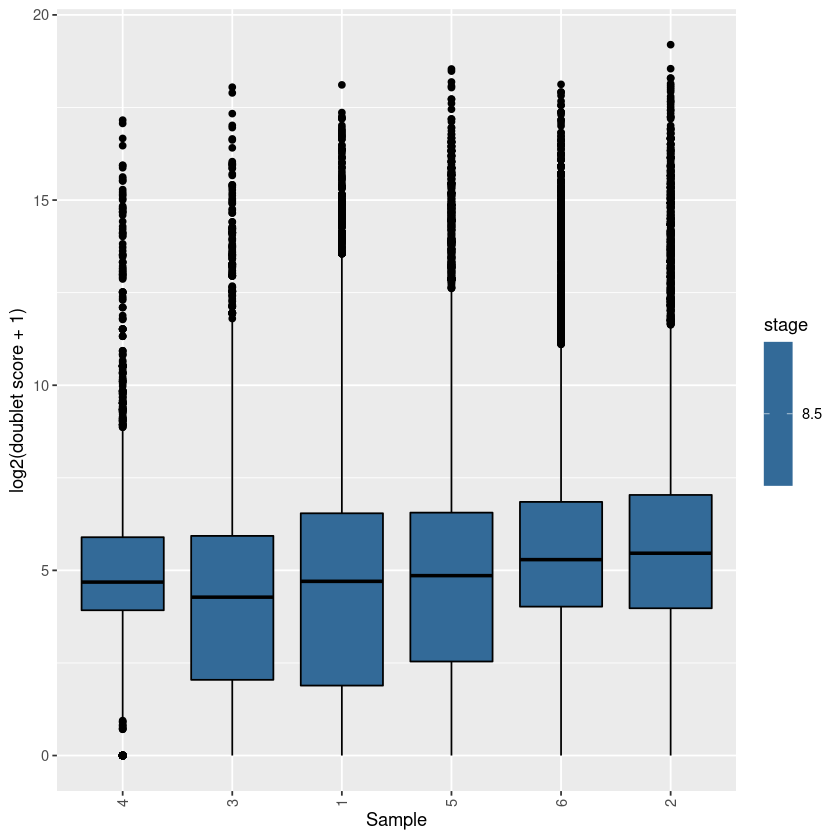

In [4]:
sampsize = melt(table(meta$sample))
order = order(sampsize$value, decreasing = FALSE)


ggplot(data.frame(score = log2(scores+1), sample = meta$sample, stage = meta$stage), aes (x = factor(sample, levels = sampsize$Var1[order]), y = score, fill = stage)) +
  geom_boxplot(col = "black") +
  theme(axis.text.x = element_text(angle = 90, vjust = 0.5)) +
  labs(y = "log2(doublet score + 1)", x = "Sample")
  # labs(y = "log2(doublet score + 1)", x = "Sample") +
  # scale_fill_manual(values = stage_colours, labels = stage_labels, name = "Stage")

Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'trendVar' is deprecated.
Use 'modelGeneVar' instead.
See help("Deprecated")”
Warning message:
“'decomposeVar' is deprecated.
Use 'modelGeneVar' instead.
See help("Deprecated")”
Warning message:
“'testVar' is deprecated.
See help("Deprecated")”
Cache found

Number of highly variable genes: 5035

Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'trendVar' is deprecated.
Use 'modelGeneVar' instead.
See help("Deprecated")”
Warning message:
“'decomposeVar' is deprecated.
Use 'modelGeneVar' instead.
See help("Deprecated")”
Warning message:
“'testVar' is deprecated.
See help("Deprecated")”
Cache found

Number of highly variable genes: 6211

Warning messag

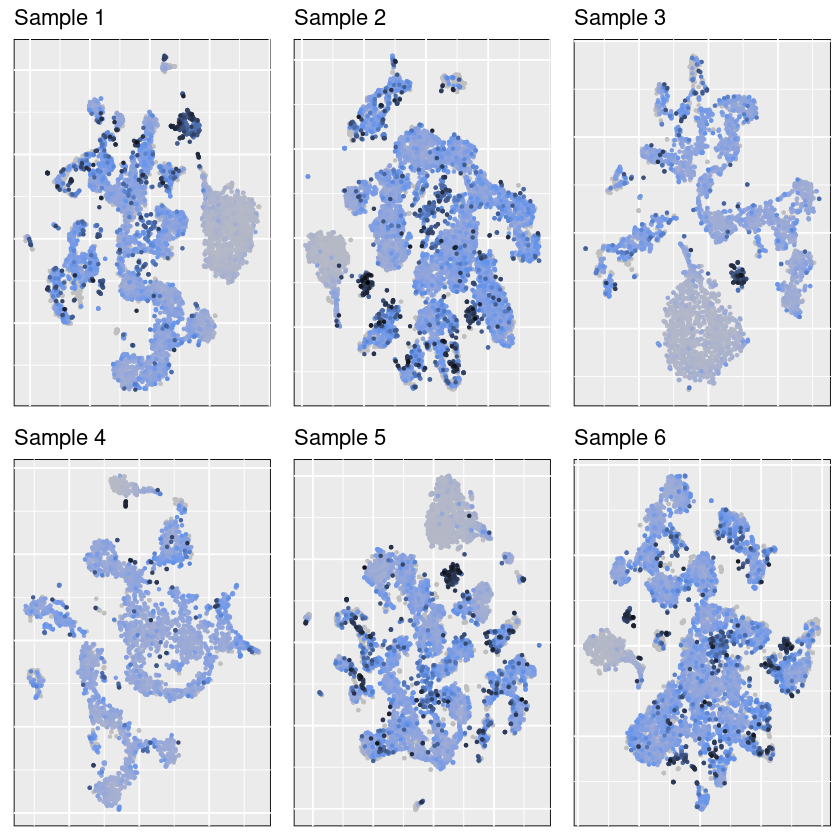

In [5]:
tsnes = lapply(unique(meta$sample), function(x){
  sub = scater::normalize(sce[, meta$sample == x])
  hvgs = getHVGs(sub)
  pca = prcomp_irlba(t(logcounts(sub[hvgs,])), n = 50)
  tsne = Rtsne(pca$x, pca = FALSE)
  return(tsne$Y)
})

names(tsnes) = unique(meta$sample)

colmax = max(log2(scores + 1))

score_plots = lapply(unique(meta$sample), function(x){
  
  scr = log2(scores[meta$sample == x] + 1)
  ord = order(scr)
  p = ggplot(as.data.frame(tsnes[[as.character(x)]])[ord,],
         aes(x = V1, y= V2, col = scr[ord])) +
    geom_point(size = 0.6) +
    scale_color_gradient2(name = "log2(score+1)", mid = "cornflowerblue", low = "gray75", high = "black", midpoint = max(colmax)/2) +
    # scale_color_viridis() +
    ggtitle(paste0("Sample ", x)) +
    theme(legend.position = "none",
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          axis.text = element_blank(),
          axis.title = element_blank(),
          panel.background = element_rect(colour = "black", linetype = 1, size = 0.5))
  
  return(p)
})

plot_grid(plotlist = score_plots)

In [6]:
clusters = lapply(unique(meta$sample), function(x){
  sub_sce = scater::normalize(sce[,meta$sample == x])
  sub_meta = meta[meta$sample == x,]

  graph = buildSNNGraph(sub_sce)
  clusters = cluster_louvain(graph)

  vec = as.numeric(membership(clusters))
  names(vec) = sub_meta$cell
  return(vec)
})

names(clusters) = unique(meta$sample)
clusters_sub = lapply(unique(meta$sample), function(x){
  sub_sce = scater::normalize(sce[,meta$sample == x])
  sub_meta = meta[meta$sample == x,]
  clusts = clusters[[as.character(x)]]

  sub_clusts = lapply(unique(clusts), function(y){
    sub_sub_sce = scater::normalize(sub_sce[,clusts == y])
    sub_sub_meta = sub_meta[clusts == y,]

    graph = buildSNNGraph(sub_sub_sce, d = min(c(ncol(sub_sub_sce)-1, 50)))
    clusters = cluster_louvain(graph)

    vec = as.numeric(membership(clusters))
    vec = paste0(y, ".", vec)
    names(vec) = sub_sub_meta$cell
    return(vec)
  })

  clusts = do.call(c, sub_clusts)
  clusts = clusts[match(meta$cell[meta$sample == x], names(clusts))]
  return(clusts)
})

clusters = do.call(c, clusters)
clusters_sub = do.call(c, clusters_sub)
clusters = clusters_sub
meta$doub.density = scores


Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning m

Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message in (function (A, nv = 5, nu = nv, maxit = 1000, work = nv + 7, reorth = TRUE, :
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecate

Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' is deprecated.
Use 'logNormCounts' instead.
See help("Deprecated")”
Warning message:
“'centreSizeFactors' is deprecated.
See help("Deprecated")”
Warning message:
“'normalizeSCE' 

In [ ]:
sample = 6

ord = order(scores[meta$sample == sample])
p1 = ggplot(as.data.frame(tsnes[[as.character(sample)]])[ord,], aes(x = V1, y= V2, col = log2(scores[meta$sample == sample]+1)[ord])) +
  geom_point(size = 0.7) +
  ggtitle(paste0("Sample ", sample, " - doublet score")) +
    theme(legend.position = "none",
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          axis.text = element_blank(),
          axis.title = element_blank(),
          panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
  # scale_color_viridis() +
  scale_color_gradient2(name = "log2(score+1)", mid = "cornflowerblue", low = "gray75", high = "black", midpoint = max(log2(scores[meta$sample == 23]+1))/2)

col2 = regmatches(clusters[meta$sample == sample], regexpr("[0-9]+", clusters[meta$sample == sample]))

p2 = ggplot(as.data.frame(tsnes[[as.character(sample)]])[ord,], aes(x = V1, y= V2, col = factor(col2)[ord])) +
  geom_point(size = 0.7) +
  ggtitle(paste0("Sample ", sample, " - clusters")) +
    theme(legend.position = "none",
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          axis.text = element_blank(),
          axis.title = element_blank(),
          panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
  scale_colour_Publication()

p3 = ggplot(as.data.frame(tsnes[[as.character(sample)]])[ord,], aes(x = V1, y= V2, col = factor(clusters[meta$sample == sample])[ord])) +
  geom_point(size = 0.7) +
  ggtitle(paste0("Sample ", sample, " - sub-clusters")) +
    theme(legend.position = "none",
          axis.line = element_blank(),
          axis.ticks = element_blank(),
          axis.text = element_blank(),
          axis.title = element_blank(),
          panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
  scale_colour_Publication()

plot_grid(p1, p2, p3, nrow = 1)

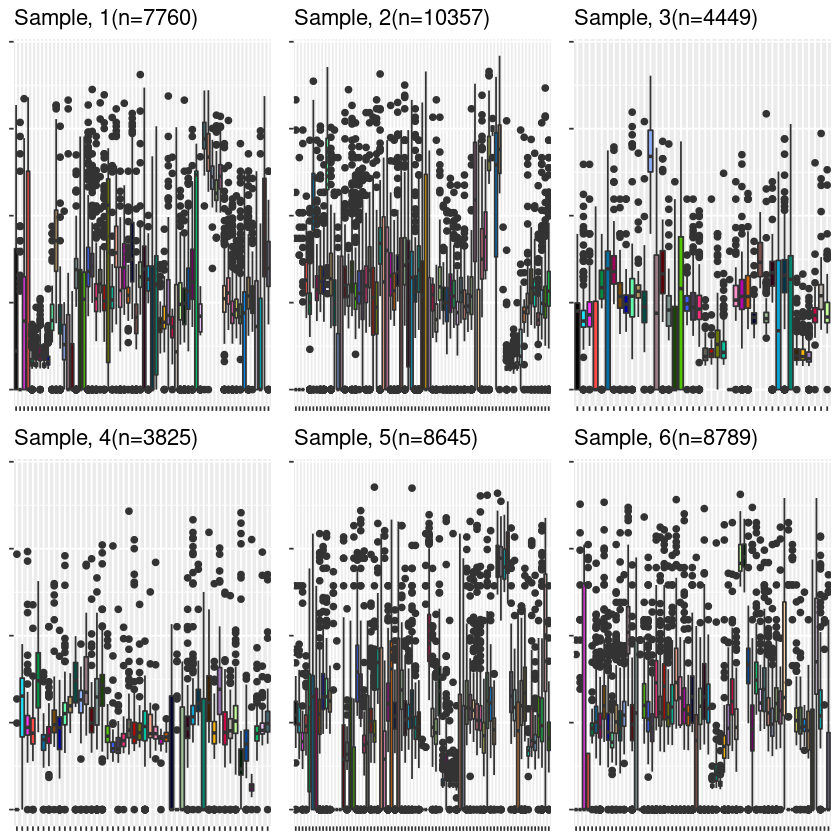

In [7]:
maxscore = max(log2(scores+1))

plots = lapply(unique(meta$sample), function(x){
  
  p = ggplot(data = data.frame(clusts = clusters[meta$sample == x],
                           scores = log2(scores[meta$sample == x] + 1)),
         mapping = aes(x = factor(clusts), y=scores, fill = factor(clusts))) +
    geom_boxplot() +
    theme(axis.text = element_blank(),
          axis.title = element_blank(),
          legend.position = "none") +
    lims(y = c(0, maxscore)) +
    scale_fill_Publication() +
    ggtitle(paste0("Sample, ", x, "(n=", sampsize$value[match(x, sampsize$Var1)], ")"))
  
  return(p)
})

plot_grid(plotlist = plots, ncol = 3)

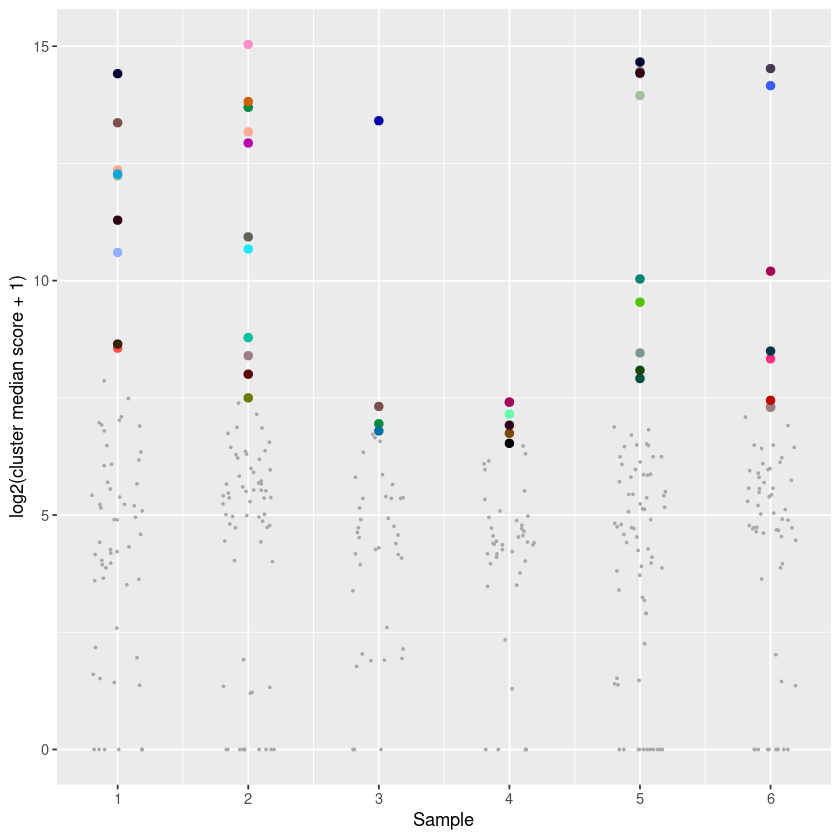

In [8]:
pdf = aggregate(meta$doub.density, list(meta$sample, clusters), median)

names(pdf) = c("sample", "cluster", "median.score")

mad_upper = function(x){
  x = x-median(x)
  return(mad(x[x>0], center = 0))
}

tests = lapply(unique(meta$sample), function(x){
  sub = pdf[pdf$sample == x,]
  scores_sample = meta$doub.density[meta$sample == x]
  sub$p.value = pnorm(sub$median.score, mean = median(sub$median.score), sd = mad_upper(sub$median.score), lower.tail = FALSE)
  return(sub)
})
pdf = do.call(rbind, tests)
pdf$fdr = p.adjust(pdf$p.value, method = "fdr")
pdf$n.cells = sapply(1:nrow(pdf), function(row){
  sum(clusters == pdf$cluster[row] & meta$sample == pdf$sample[row])
})

pdf$frac.cells = sapply(1:nrow(pdf), function(row){
  pdf$n.cells[row]/sum(pdf$n.cells[pdf$sample == pdf$sample[row]])
})



ggplot(pdf, aes(x = sample, y = log2(median.score + 1), col = factor(cluster))) +
  geom_point(data = pdf[pdf$fdr < 0.1,], size = 2) +
  geom_jitter(data = pdf[pdf$fdr >= 0.1,], col = "darkgrey", size = 0.4, width = 0.2, height = 0) +
  scale_colour_Publication() +
  theme(legend.position = "none") +
  scale_x_continuous(breaks = 1:max(pdf$sample)) +
  labs(x = "Sample", y = "log2(cluster median score + 1)")

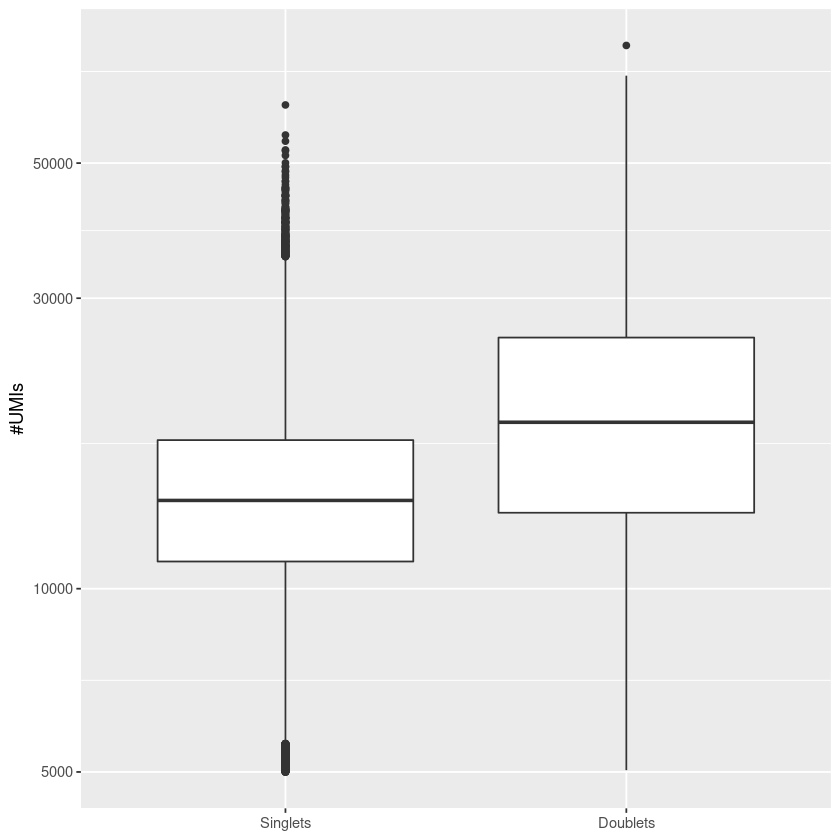

In [9]:
doub.call = paste(meta$sample, clusters) %in% paste(pdf$sample, pdf$cluster)[pdf$fdr < 0.1]

libs = Matrix::colSums(counts(sce))

ggplot(mapping = aes(x = doub.call, y = libs)) +
  geom_boxplot() +
  scale_x_discrete(labels = c("FALSE" = "Singlets", "TRUE" = "Doublets")) +
  theme(axis.title.x = element_blank()) +
  labs(y = "#UMIs") +
  scale_y_log10()

ERROR while rich displaying an object: Error: Continuous value supplied to discrete scale

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
7. repr::mime2repr[[mime]](obj)
8. repr_text.default(obj)
9. paste(cap

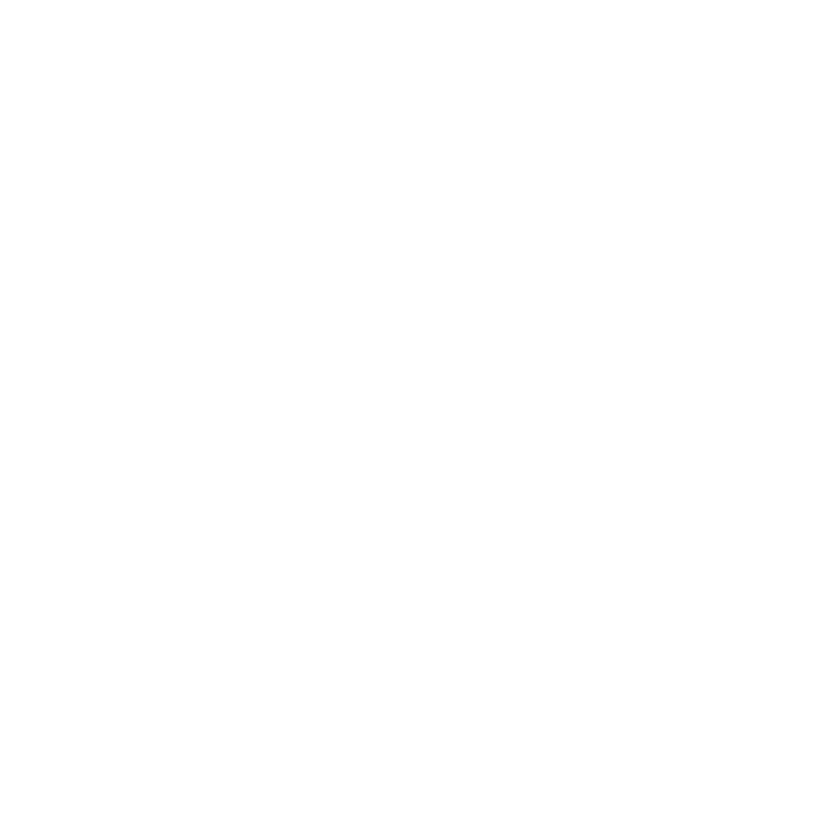

In [10]:
fd = sapply(unique(meta$sample), function(x){
  sum(doub.call[meta$sample == x])/sum(meta$sample == x)
})

nc = sapply(unique(meta$sample), function(x){
  sum(meta$sample == x)
})

frac_doubs = ggplot(mapping = aes(x = nc, y = fd, fill = meta$stage[match(unique(meta$sample), meta$sample)])) + 
  geom_point(shape = 21, size = 4, alpha = 1) +
  scale_fill_manual(values = stage_colours, labels = stage_labels, name = "Stage") +
  labs(x = "Number of cells", y = "Fraction of called doublets")

frac_doubs

In [11]:
xist_on = counts(sce)[match("Xist", genes[,2]),]>0

db = useMart("ensembl", dataset = "mmusculus_gene_ensembl")
gene_map = getBM(attributes = c("ensembl_gene_id", "chromosome_name"), filters = "ensembl_gene_id", values = genes[,1], mart = db)
sex_genes = c(gene_map[gene_map[,2] == "Y",1])
sex_genes = sex_genes[sex_genes != "ENSMUSG00000096768"] #this gene has an X chromosome paralogue Erdr1 - exclude

y_on = Matrix::colSums(counts(sce)[match(sex_genes, genes[,1]),] > 0 )>0

sex = xist_on & y_on

pdf$sex.frac = sapply(1:nrow(pdf), function(row){
  select = clusters == pdf$cluster[row] & meta$sample == pdf$sample[row]
  return(sum(sex[select])/sum(select))
})

pdf$stage = meta$stage[match(pdf$sample, meta$sample)]


pdf$call = pdf$fdr < 0.1

xist_plot = ggplot(pdf, aes(y = sex.frac, x = stage, fill = call)) +
  geom_boxplot() +
  scale_fill_brewer(palette = "Paired", labels = c("FALSE" = "Singlet", "TRUE" = "Doublet"), name = "") +
  theme(axis.title.x = element_blank()) +
  scale_x_discrete(labels = stage_labels) +
  labs(y = "Fraction of cells coexpressing Xist + Y-CHR")

xist_plot

ERROR: Error in `[.data.frame`(genes, , 2): undefined columns selected


In [12]:
hvgs = getHVGs(sce)

pca = prcomp_irlba(t(logcounts(sce)[hvgs,]), n = 50)
hvgs = getHVGs(sce)

Warning message:
“'trendVar' is deprecated.
Use 'modelGeneVar' instead.
See help("Deprecated")”
Warning message:
“'decomposeVar' is deprecated.
Use 'modelGeneVar' instead.
See help("Deprecated")”
Warning message:
“'testVar' is deprecated.
See help("Deprecated")”
Cache found

Number of highly variable genes: 6989

Warning message:
“'trendVar' is deprecated.
Use 'modelGeneVar' instead.
See help("Deprecated")”
Warning message:
“'decomposeVar' is deprecated.
Use 'modelGeneVar' instead.
See help("Deprecated")”
Warning message:
“'testVar' is deprecated.
See help("Deprecated")”
Cache found

Number of highly variable genes: 6989



In [15]:
library(batchelor)

In [16]:
#get order: oldest to youngest; most cells to least cells
order_df = meta[!duplicated(meta$sample), c("stage", "sample")]
order_df$ncells = sapply(order_df$sample, function(x) sum(meta$sample == x))
order_df$stage = factor(order_df$stage, 
                        levels = rev(c("E8.5")))
                        
order_df = order_df[order(order_df$stage, order_df$ncells, decreasing = TRUE),]
order_df$stage = as.character(order_df$stage)

all_correct = doBatchCorrect(counts = logcounts(sce)[rownames(sce) %in% hvgs,], 
                             timepoints = meta$stage, 
                             samples = meta$sample, 
                             timepoint_order = order_df$stage, 
                             sample_order = order_df$sample, 
                             npc = 50)

Warning message:
“'pc.input=TRUE' and 'use.dimred=TRUE' are deprecated.
Use 'reducedMNN' instead.”


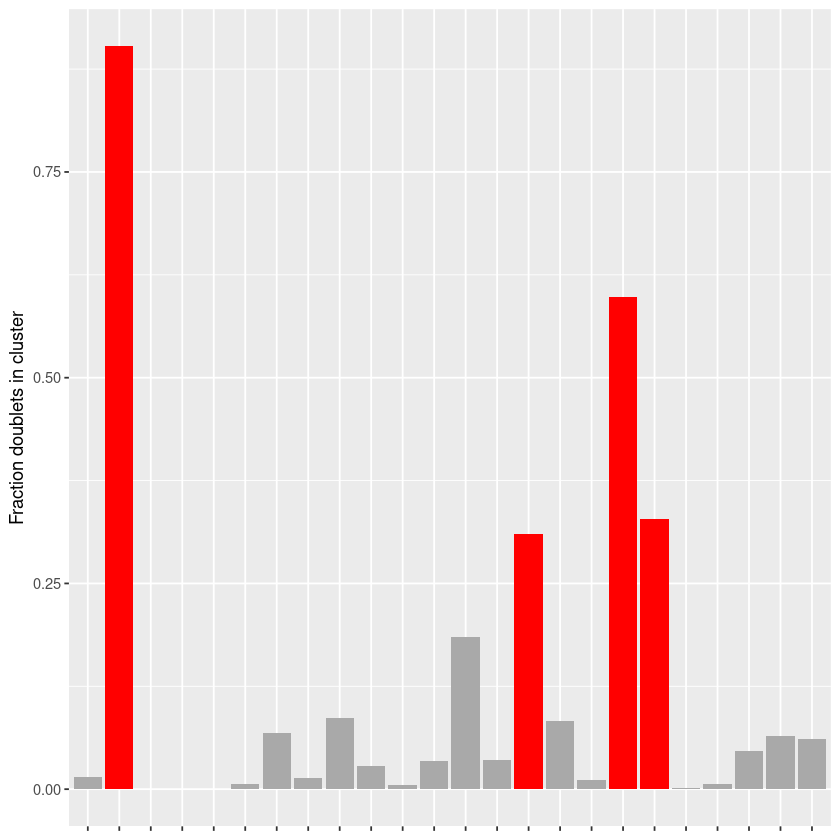

In [17]:
tsne = Rtsne(all_correct, pca = FALSE)$Y

graph = buildSNNGraph(all_correct, d = NA, transposed = TRUE)
set.seed(42)
clusts = as.numeric(membership(cluster_louvain(graph)))
names(clusts) = meta$cell

tab = table(clusts, doub.call)
tab = as.data.frame(sweep(tab, 1, rowSums(tab), "/"))
tab = tab[as.logical(tab$doub.call),c(1,3)]
tab$p = pnorm(tab$Freq, mean = median(tab$Freq), sd = mad_upper(tab$Freq), lower.tail = FALSE)
tab$fdr = p.adjust(tab$p, method = "fdr")

ggplot(mapping = aes(x = factor(rownames(tab), levels = rownames(tab)), y = tab[,2], fill = tab$fdr < 0.1)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "darkgrey")) +
  theme(legend.position = "none", axis.text.x = element_blank(), axis.title.x = element_blank()) +
  labs(y = "Fraction doublets in cluster")

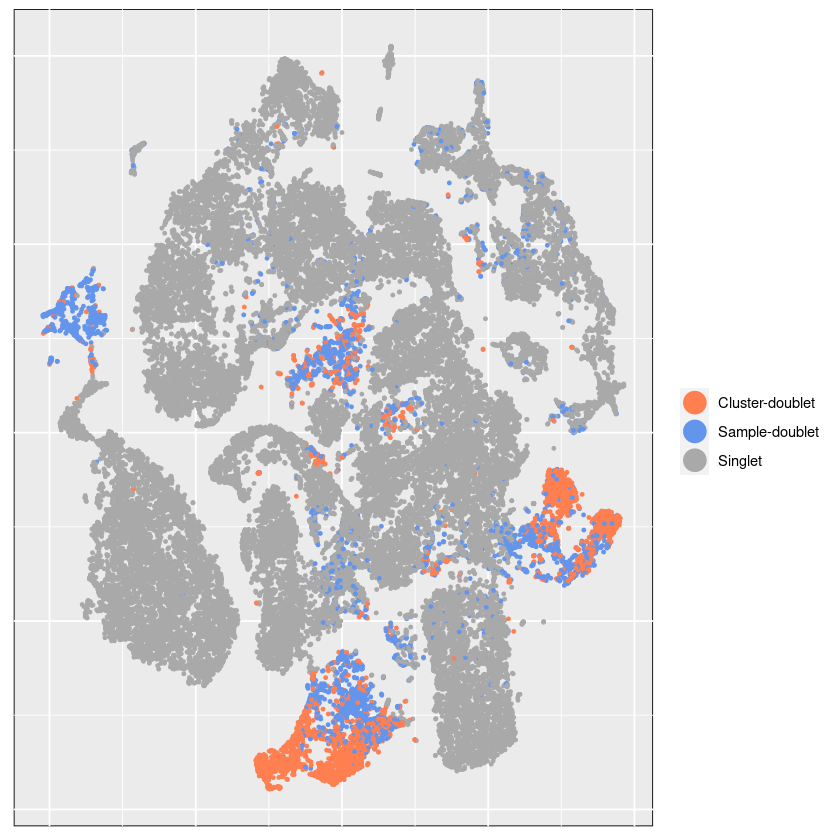

In [18]:
cluster_calls = clusts %in% tab$clusts[tab$fdr < 0.1]

cell_calls = doub.call
state = rep("Singlet", nrow(meta))
state[cluster_calls] = "Cluster-doublet"
state[cell_calls] = "Sample-doublet"

# ord = order(factor(state, levels = c("Singlet", "Cluster-doublet", "Sample-doublet")))
ord = sample(length(state), length(state))

ggplot(as.data.frame(tsne)[ord,], aes(x = V1, y= V2, col = state[ord])) +
    geom_point(size = 0.7) +
      theme(axis.line = element_blank(),
            axis.ticks = element_blank(),
            axis.text = element_blank(),
            axis.title = element_blank(),
            panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
    scale_colour_manual(values = c("Singlet" = "darkgrey", "Cluster-doublet" = "coral", "Sample-doublet" = "cornflowerblue"),
                        name = "") +
    guides(colour = guide_legend(override.aes = list(size=6)))

Warning message:
“Removed 36065 rows containing missing values (geom_point).”
Warning message:
“Removed 33468 rows containing missing values (geom_point).”
Warning message:
“Removed 39376 rows containing missing values (geom_point).”
Warning message:
“Removed 40000 rows containing missing values (geom_point).”
Warning message:
“Removed 35180 rows containing missing values (geom_point).”
Warning message:
“Removed 35036 rows containing missing values (geom_point).”


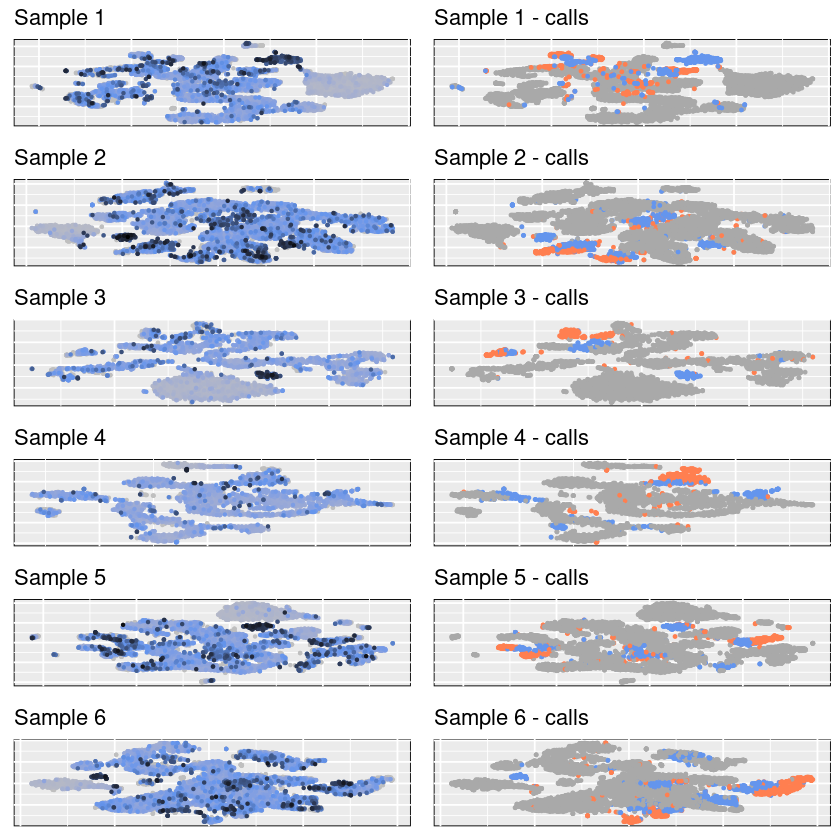

In [19]:
plots_calls = lapply(unique(meta$sample), function(x){
  keep = meta$sample == x
  ord = order(factor(state, levels = c("Singlet", "Cluster-doublet", "Sample-doublet")[keep]))
  state_sub = state[keep]
  ggplot(as.data.frame(tsnes[[as.character(x)]])[ord,], aes(x = V1, y= V2,
                                                                   col = state_sub[ord])) +
    geom_point(size = 0.7) +
    ggtitle(paste0("Sample ", x, " - calls")) +
      theme(legend.position = "none",
            axis.line = element_blank(),
            axis.ticks = element_blank(),
            axis.text = element_blank(),
            axis.title = element_blank(),
            panel.background = element_rect(colour = "black", linetype = 1, size = 0.5)) +
    scale_colour_manual(values = c("Singlet" = "darkgrey", "Cluster-doublet" = "coral", "Sample-doublet" = "cornflowerblue"))
})

grids = lapply(1:length(plots_calls), function(x) plot_grid(score_plots[[x]], plots_calls[[x]]))
grid = plot_grid(plotlist = grids, ncol =1)

plot(grid)

In [8]:
meta$doublet = state != "Singlet"

Cache found



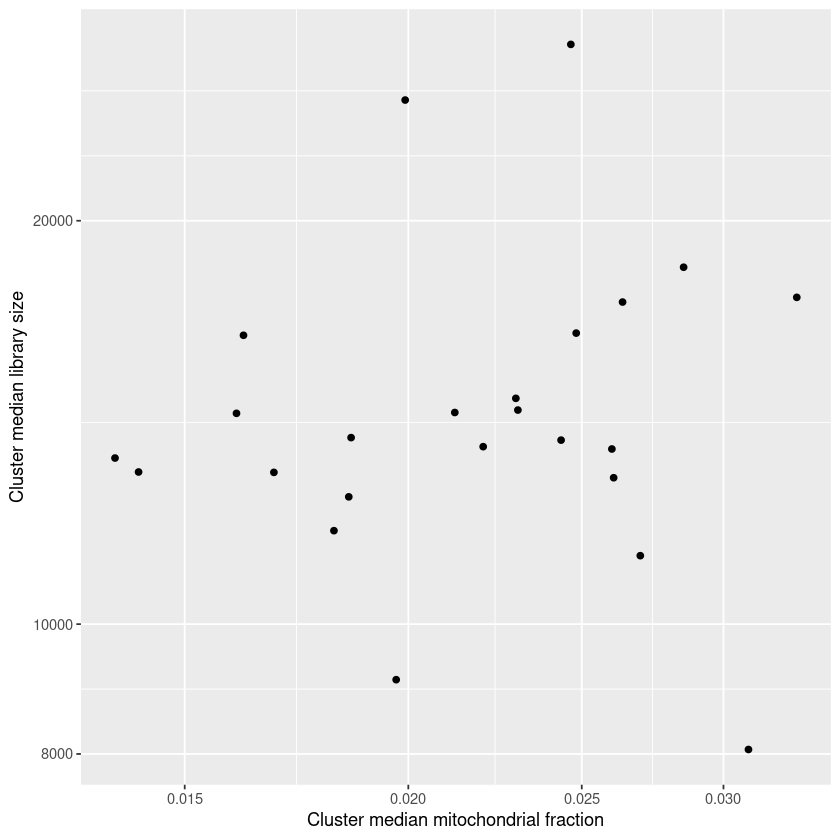

In [4]:
mouse_ensembl = useMart("ensembl")
mouse_ensembl = useDataset("mmusculus_gene_ensembl", mart = mouse_ensembl)

gene_map = getBM(attributes=c("ensembl_gene_id", "chromosome_name"), values = genes[,1], mart = mouse_ensembl)

mt.counts = counts(sce)[which(genes[,1] %in% gene_map$ensembl_gene_id[gene_map$chromosome_name=="MT"]), ]
mt.fraction = Matrix::colSums(mt.counts)/Matrix::colSums(counts(sce))
libsizes = Matrix::colSums(counts(sce))


meds = data.frame(mt = sapply(unique(clusts), function(x) median(mt.fraction[clusts == x])),
                  lib = sapply(unique(clusts), function(x) median(libsizes[clusts == x])),
                  cluster = unique(clusts))

meds$stripped = meds$mt < 0.005



ggplot(meds, aes (x = mt, y = lib, col = stripped)) +
  geom_point() +
  labs(x = "Cluster median mitochondrial fraction",
       y = "Cluster median library size") +
  scale_x_log10() + 
  scale_y_log10() +
  theme(legend.position = "none") +
  scale_color_manual(values = c("TRUE" = "red", "FALSE" = "black"))

In [11]:
meta$stripped = clusts %in% meds$cluster[meds$stripped]

In [12]:
meta

cell,barcode,sample,stage,batch,stripped,doublet
<chr>,<chr>,<int>,<dbl>,<int>,<lgl>,<lgl>
cell_1,AAACCCAAGCATAGGC,1,8.5,1,FALSE,FALSE
cell_2,AAACCCAAGGGACTGT,1,8.5,1,FALSE,FALSE
cell_3,AAACCCACAAGCAATA,1,8.5,1,FALSE,FALSE
cell_4,AAACCCACATCTTCGC,1,8.5,1,FALSE,FALSE
cell_5,AAACCCAGTATCTCTT,1,8.5,1,FALSE,FALSE
cell_6,AAACCCAGTCCAATCA,1,8.5,1,FALSE,FALSE
cell_7,AAACCCATCACTCCGT,1,8.5,1,FALSE,TRUE
cell_8,AAACCCATCAGCCTTC,1,8.5,1,FALSE,FALSE
cell_9,AAACCCATCATTGCGA,1,8.5,1,FALSE,FALSE


In [13]:
kable(table(ifelse(meta$doublet, "Doublet", "Singlet"), meta$stage), caption = "Number of called doublets at each developmental timepoint.")
kable(table(ifelse(meta$stripped, "Stripped", "Normal"), meta$stage), caption = "Number of called stripped nuclei at each developmental timepoint.")



|        |   8.5|
|:-------|-----:|
|Doublet |  6617|
|Singlet | 37208|



|       |   8.5|
|:------|-----:|
|Normal | 43825|

In [14]:
write.table(meta, file = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/5_doubletDetection/meta.tab", sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)
save(list = ls(), file = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/5_doubletDetection/debug.RData")

In [15]:
save.image("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/5_doubletDetection/workspace_220520.RData")

In [ ]:
load("/rds/project/bg200/rds-bg200-hphi-gottgens/users/mlnt2/PhD_MT07_Mixl1/5_doubletDetection/workspace_220520.RData")